# Agrupamiento espectral
## Minired SP500

Esta practica pide aplicar el algoritmo del tutorial a la **minired** del SP500 y justificar el tratamiento cuando la red es **dirigida** y **disconexa**.

Aqui la red original representa relaciones proveedor-cliente (`u -> v` significa "u provee a v"). Para la lectura economica la direccion importa,
pero la Laplaciana del tutorial y las funciones `laplacian_spectrum`, `fiedler_vector`, `spectral_ordering` y `spectral_bisection` trabajan sobre una version **simetrica**.
Por eso hago el analisis sobre la **red subyacente no dirigida** y dejo la direccion como contexto interpretativo.

In [1]:
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from networkx.algorithms.community import greedy_modularity_communities

SEED = 863

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.options.display.max_colwidth = 200

La red completa no es conexa: tiene dos componentes no dirigidas. Eso significa que el espectro Laplaciano del grafo completo debe empezar con **dos ceros**,
y que la biseccion espectral no se aplica directamente al todo. Primero separo componentes y luego decido cuales siguen siendo candidatas a subdividir,
guiandome por su **conectividad algebraica** $\lambda_2$.

In [2]:
def get_display_labels(G):
    raw = nx.get_node_attributes(G, "label")
    return {node: raw.get(node, str(node)) for node in G.nodes()}


def rounded_list(values, digits=6):
    return [round(float(x), digits) for x in np.asarray(values, dtype=float)]


def communities_to_lookup(communities):
    lookup = {}
    for idx, community in enumerate(communities):
        for node in community:
            lookup[node] = idx
    return lookup


def algebraic_connectivity_safe(G, weight=None):
    if G.number_of_nodes() < 2 or not nx.is_connected(G):
        return 0.0
    return float(nx.algebraic_connectivity(G, weight=weight))


def spectral_report(G, labels, title, weight=None):
    print("=" * 100)
    print(title)
    print(f"nodos = {G.number_of_nodes()}, aristas = {G.number_of_edges()}, conexa = {nx.is_connected(G)}")
    spectrum = rounded_list(nx.laplacian_spectrum(G, weight=weight))
    print("laplacian_spectrum =", spectrum)
    result = {
        "title": title,
        "spectrum": spectrum,
        "groups": [set(G.nodes())],
        "lambda2": 0.0,
    }
    if not nx.is_connected(G):
        component_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
        print("La subred no es conexa; antes de bisectar hay que separar componentes.")
        print("tamano_componentes =", component_sizes)
        return result
    lambda2 = algebraic_connectivity_safe(G, weight=weight)
    fiedler = nx.fiedler_vector(G, weight=weight)
    ordering = list(nx.spectral_ordering(G, weight=weight))
    groups = [set(part) for part in nx.spectral_bisection(G, weight=weight)]
    print(f"lambda_2 = {lambda2:.6f}")
    print("spectral_ordering =", [labels[node] for node in ordering])
    print("grupo_1 =", sorted(labels[node] for node in groups[0]))
    print("grupo_2 =", sorted(labels[node] for node in groups[1]))
    fiedler_df = (
        pd.DataFrame(
            {
                "nodo": [labels[node] for node in G.nodes()],
                "componente_fiedler": fiedler,
                "signo": np.where(fiedler >= 0, "+", "-"),
            }
        )
        .sort_values("componente_fiedler")
        .reset_index(drop=True)
    )
    display(fiedler_df.round(4))
    result.update(
        {
            "lambda2": lambda2,
            "ordering": ordering,
            "groups": groups,
            "fiedler_df": fiedler_df,
        }
    )
    return result


def partition_summary(G, communities, labels, weight=None):
    rows = []
    for idx, community in enumerate(sorted([set(c) for c in communities], key=len, reverse=True), start=1):
        SG = G.subgraph(community).copy()
        rows.append(
            {
                "grupo": idx,
                "nodos": len(community),
                "aristas_internas": SG.number_of_edges(),
                "densidad": round(nx.density(SG), 4) if len(community) > 1 else 0.0,
                "lambda_2": round(algebraic_connectivity_safe(SG, weight=weight), 4),
                "miembros": ", ".join(sorted(labels[node] for node in community)),
            }
        )
    return pd.DataFrame(rows)


def draw_partition(ax, G, communities, labels, title, pos=None):
    groups = [set(c) for c in communities]
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    lookup = communities_to_lookup(groups)
    node_colors = [lookup[node] for node in G.nodes()]
    node_sizes = [220 + 20 * G.degree(node) for node in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=1.0, edge_color="#94a3b8")
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        cmap="nipy_spectral",
        linewidths=0.8,
        edgecolors="white",
    )
    font_size = 9 if G.number_of_nodes() <= 25 else 7
    nx.draw_networkx_labels(G, pos, ax=ax, labels=labels, font_size=font_size)
    ax.set_title(title)
    ax.axis("off")
    return pos


def plot_partition_sequence(G, labels, states, pos=None, ncols=2, figsize=(18, 12)):
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    nrows = int(np.ceil(len(states) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, state in zip(axes, states):
        draw_partition(ax, G, state["groups"], labels, state["title"], pos=pos)
    for ax in axes[len(states):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def comparison_table(entries):
    return pd.DataFrame(entries).sort_values(["grafo", "Q"], ascending=[True, False]).reset_index(drop=True)

from typing import List, Tuple

V: List[str] = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "GOOG", "AVGO", "META", "TSLA", "BRK.B",
    "JPM", "V", "MA", "WMT", "COST", "ORCL", "LLY", "XOM", "JNJ", "PLTR",
    "BAC", "ABBV", "MU", "HD", "NFLX", "AMD", "PG", "GE", "CVX", "UNH",
]

E: List[Tuple[str, str]] = [
    ("MU", "NVDA"), ("AVGO", "AAPL"),
    ("NVDA", "MSFT"), ("NVDA", "AMZN"), ("NVDA", "GOOG"), ("NVDA", "GOOGL"),
    ("NVDA", "ORCL"), ("NVDA", "META"), ("NVDA", "TSLA"),
    ("AMD", "AMZN"), ("AMD", "MSFT"), ("AMD", "ORCL"), ("AMD", "TSLA"),
    ("AMZN", "NFLX"), ("AMZN", "XOM"), ("AMZN", "JNJ"), ("AMZN", "ABBV"), ("AMZN", "PLTR"),
    ("MSFT", "CVX"), ("MSFT", "GE"), ("MSFT", "UNH"), ("MSFT", "PLTR"),
    ("GOOGL", "PLTR"), ("ORCL", "PLTR"),
    ("AAPL", "WMT"), ("AAPL", "COST"), ("PG", "WMT"), ("BRK.B", "WMT"),
    ("V", "COST"), ("V", "HD"), ("V", "BAC"),
    ("MA", "HD"), ("MA", "WMT"), ("MA", "AAPL"), ("MA", "BAC"),
    ("JPM", "AAPL"),
    ("LLY", "AMZN"),
]

G_dir = nx.DiGraph()
G_dir.add_nodes_from(V)
G_dir.add_edges_from(E)
for node in G_dir.nodes():
    G_dir.nodes[node]["label"] = node

# Para la Laplaciana del tutorial uso la red subyacente no dirigida.
G_sp = G_dir.to_undirected()
for node in G_sp.nodes():
    G_sp.nodes[node]["label"] = node

labels_sp = get_display_labels(G_sp)
pos_sp = nx.spring_layout(G_sp, seed=SEED, k=1.2)
componentes_sp = [set(c) for c in sorted(nx.connected_components(G_sp), key=len, reverse=True)]

resumen_sp = pd.DataFrame(
    [
        {
            "nodos": G_dir.number_of_nodes(),
            "aristas_dirigidas": G_dir.number_of_edges(),
            "componentes_fuertemente_conexas": nx.number_strongly_connected_components(G_dir),
            "componentes_debilmente_conexas": nx.number_weakly_connected_components(G_dir),
            "componentes_no_dirigidas": nx.number_connected_components(G_sp),
            "tamano_componentes": str([len(c) for c in componentes_sp]),
        }
    ]
)

display(resumen_sp)
print("laplacian_spectrum(G subyacente) =", rounded_list(nx.laplacian_spectrum(G_sp)))

resumen_componentes_sp = pd.DataFrame(
    [
        {
            "componente": idx + 1,
            "nodos": len(comp),
            "lambda_2": round(algebraic_connectivity_safe(G_sp.subgraph(comp).copy()), 4),
            "miembros": ", ".join(sorted(comp)),
        }
        for idx, comp in enumerate(componentes_sp)
    ]
)

display(resumen_componentes_sp)

,nodos,aristas_dirigidas,componentes_fuertemente_conexas,componentes_debilmente_conexas,componentes_no_dirigidas,tamano_componentes
0,30,37,30,2,2,"[19, 11]"


laplacian_spectrum(G subyacente) = [-0.0, -0.0, 0.394933, 0.499826, 0.553077, 0.63612, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.182867, 1.585786, 1.704603, 2.0, 2.412673, 2.909774, 4.351097, 4.414214, 4.4595, 5.593671, 6.304908, 6.714569, 8.086994, 10.195387]


,componente,nodos,lambda_2,miembros
0,1,19,0.3949,"ABBV, AMD, AMZN, CVX, GE, GOOG, GOOGL, JNJ, LLY, META, MSFT, MU, NFLX, NVDA, ORCL, PLTR, TSLA, UNH, XOM"
1,2,11,0.4998,"AAPL, AVGO, BAC, BRK.B, COST, HD, JPM, MA, PG, V, WMT"


## 1. Componentes candidatas a dividir

In [3]:
G_sp_c1 = G_sp.subgraph(componentes_sp[0]).copy()
G_sp_c2 = G_sp.subgraph(componentes_sp[1]).copy()

report_sp_c1 = spectral_report(G_sp_c1, labels_sp, "Paso 1. Componente principal de 19 nodos")
report_sp_c2 = spectral_report(G_sp_c2, labels_sp, "Paso 2. Segunda componente de 11 nodos")

coarse_partition_sp = sorted(
    [set(part) for part in report_sp_c1["groups"]] + [set(part) for part in report_sp_c2["groups"]],
    key=len,
    reverse=True,
)

print("\nResumen de la particion espectral gruesa (4 grupos)")
display(partition_summary(G_sp, coarse_partition_sp, labels_sp))

Paso 1. Componente principal de 19 nodos
nodos = 19, aristas = 24, conexa = True
laplacian_spectrum = [0.0, 0.394933, 0.553077, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.182867, 1.585786, 2.412673, 4.414214, 4.4595, 6.714569, 8.086994, 10.195387]
lambda_2 = 0.394933
spectral_ordering = ['XOM', 'LLY', 'NFLX', 'JNJ', 'ABBV', 'AMZN', 'PLTR', 'AMD', 'ORCL', 'GOOGL', 'TSLA', 'NVDA', 'GOOG', 'MU', 'META', 'MSFT', 'GE', 'CVX', 'UNH']
grupo_1 = ['AMD', 'CVX', 'GE', 'GOOG', 'GOOGL', 'META', 'MSFT', 'MU', 'NVDA', 'ORCL', 'PLTR', 'TSLA', 'UNH']
grupo_2 = ['ABBV', 'AMZN', 'JNJ', 'LLY', 'NFLX', 'XOM']


,nodo,componente_fiedler,signo
0,CVX,-0.3329,-
1,UNH,-0.3329,-
2,GE,-0.3329,-
3,MSFT,-0.2014,-
4,META,-0.1100,-
5,GOOG,-0.1100,-
6,MU,-0.1100,-
7,NVDA,-0.0666,-
8,GOOGL,-0.0613,-
9,TSLA,-0.0613,-


Paso 2. Segunda componente de 11 nodos
nodos = 11, aristas = 13, conexa = True
laplacian_spectrum = [0.0, 0.499826, 0.63612, 1.0, 1.0, 1.704603, 2.0, 2.909774, 4.351097, 5.593671, 6.304908]
lambda_2 = 0.499826
spectral_ordering = ['V', 'HD', 'BAC', 'COST', 'AVGO', 'JPM', 'MA', 'AAPL', 'WMT', 'PG', 'BRK.B']
grupo_1 = ['AAPL', 'AVGO', 'BAC', 'COST', 'HD', 'JPM', 'MA', 'V']
grupo_2 = ['BRK.B', 'PG', 'WMT']


,nodo,componente_fiedler,signo
0,V,-0.2883,-
1,BAC,-0.2436,-
2,HD,-0.2436,-
3,COST,-0.2337,-
4,JPM,-0.1244,-
5,AVGO,-0.1244,-
6,MA,-0.0771,-
7,AAPL,-0.0622,-
8,WMT,0.2795,+
9,PG,0.5589,+



Resumen de la particion espectral gruesa (4 grupos)


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,13,16,0.2051,0.5124,"AMD, CVX, GE, GOOG, GOOGL, META, MSFT, MU, NVDA, ORCL, PLTR, TSLA, UNH"
1,2,8,9,0.3214,0.5598,"AAPL, AVGO, BAC, COST, HD, JPM, MA, V"
2,3,6,5,0.3333,1.0000,"ABBV, AMZN, JNJ, LLY, NFLX, XOM"
3,4,3,2,0.6667,1.0000,"BRK.B, PG, WMT"


**Como elijo las componentes a dividir**

- La red completa tiene dos componentes, asi que el primer mensaje del espectro es trivial: `lambda_2 = 0` porque el grafo esta desconectado.
- La componente principal tiene $\lambda_2 pprox 0.395$ y la segunda $\lambda_2 pprox 0.500$. Las dos son relativamente bajas, asi que **ambas son candidatas razonables**.
- El primer corte de la componente grande separa el bloque `AMZN-ABBV-JNJ-LLY-NFLX-XOM` del resto; el primer corte de la otra componente separa `BRK.B-PG-WMT` del bloque `AAPL-MA-V-COST-HD-BAC-JPM-AVGO`.
- A ese nivel ya aparece una particion gruesa de 4 grupos que es bastante interpretable, pero todavia quedan dos subredes con $\lambda_2$ en torno a `0.51` y `0.56`, asi que muestro una ronda adicional de refinamiento.

## 2. Refinamiento de las subredes menos cohesionadas

In [4]:
sp_c1_big = max(report_sp_c1["groups"], key=len)
sp_c2_big = max(report_sp_c2["groups"], key=len)

report_sp_c1_big = spectral_report(
    G_sp.subgraph(sp_c1_big).copy(),
    labels_sp,
    "Paso 3. Se subdivide el bloque grande de la componente principal",
)
report_sp_c2_big = spectral_report(
    G_sp.subgraph(sp_c2_big).copy(),
    labels_sp,
    "Paso 4. Se subdivide el bloque grande de la segunda componente",
)

refined_partition_sp = []
for part in report_sp_c1["groups"]:
    if set(part) == set(sp_c1_big):
        refined_partition_sp.extend([set(child) for child in report_sp_c1_big["groups"]])
    else:
        refined_partition_sp.append(set(part))
for part in report_sp_c2["groups"]:
    if set(part) == set(sp_c2_big):
        refined_partition_sp.extend([set(child) for child in report_sp_c2_big["groups"]])
    else:
        refined_partition_sp.append(set(part))
refined_partition_sp = sorted(refined_partition_sp, key=len, reverse=True)

print("\nResumen de la particion espectral refinada (6 grupos)")
display(partition_summary(G_sp, refined_partition_sp, labels_sp))

Paso 3. Se subdivide el bloque grande de la componente principal
nodos = 13, aristas = 16, conexa = True
laplacian_spectrum = [-0.0, 0.512416, 1.0, 1.0, 1.0, 1.0, 1.0, 1.381966, 2.334705, 3.618034, 4.140007, 6.39879, 8.614082]
lambda_2 = 0.512416
spectral_ordering = ['CVX', 'UNH', 'GE', 'MSFT', 'AMD', 'PLTR', 'ORCL', 'TSLA', 'GOOGL', 'NVDA', 'MU', 'META', 'GOOG']
grupo_1 = ['AMD', 'CVX', 'GE', 'MSFT', 'PLTR', 'UNH']
grupo_2 = ['GOOG', 'GOOGL', 'META', 'MU', 'NVDA', 'ORCL', 'TSLA']


,nodo,componente_fiedler,signo
0,CVX,-0.4189,-
1,UNH,-0.4189,-
2,GE,-0.4189,-
3,MSFT,-0.2043,-
4,PLTR,-0.0185,-
5,AMD,-0.0185,-
6,ORCL,0.0546,+
7,GOOGL,0.1037,+
8,TSLA,0.1037,+
9,NVDA,0.1728,+


Paso 4. Se subdivide el bloque grande de la segunda componente
nodos = 8, aristas = 9, conexa = True
laplacian_spectrum = [-0.0, 0.559839, 1.0, 1.625482, 2.0, 2.843816, 4.63326, 5.337602]
lambda_2 = 0.559839
spectral_ordering = ['BAC', 'HD', 'V', 'MA', 'COST', 'AAPL', 'JPM', 'AVGO']
grupo_1 = ['BAC', 'COST', 'HD', 'MA', 'V']
grupo_2 = ['AAPL', 'AVGO', 'JPM']


,nodo,componente_fiedler,signo
0,HD,-0.3556,-
1,BAC,-0.3556,-
2,V,-0.3154,-
3,MA,-0.1967,-
4,COST,-0.0585,-
5,AAPL,0.2312,+
6,AVGO,0.5253,+
7,JPM,0.5253,+



Resumen de la particion espectral refinada (6 grupos)


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,7,6,0.2857,1.0000,"GOOG, GOOGL, META, MU, NVDA, ORCL, TSLA"
1,2,6,5,0.3333,1.0000,"AMD, CVX, GE, MSFT, PLTR, UNH"
2,3,6,5,0.3333,1.0000,"ABBV, AMZN, JNJ, LLY, NFLX, XOM"
3,4,5,5,0.5000,0.8299,"BAC, COST, HD, MA, V"
4,5,3,2,0.6667,1.0000,"AAPL, AVGO, JPM"
5,6,3,2,0.6667,1.0000,"BRK.B, PG, WMT"


**Interpretacion economica de los cortes**

- En la componente principal, el vector de Fiedler primero separa un bloque muy claro de empresas colgadas de `AMZN`: `ABBV`, `JNJ`, `LLY`, `NFLX` y `XOM`. Es natural: todas dependen del mismo hub y casi no tienen relaciones laterales entre si.
- La subred grande que queda aun tiene una cohesion moderada, y la siguiente biseccion separa un frente **corporativo/servicios** (`MSFT`, `CVX`, `GE`, `UNH`, `AMD`, `PLTR`) de un frente **computo-plataformas** (`NVDA`, `GOOG`, `GOOGL`, `META`, `MU`, `ORCL`, `TSLA`).
- En la segunda componente, el primer corte despega la rama `BRK.B-PG-WMT`, mientras que el bloque grande restante todavia admite una subdivision entre `AAPL-AVGO-JPM` y `V-MA-COST-HD-BAC`.
- Las hojas finales quedan con $\lambda_2$ cercano a `0.83` o `1.00`, asi que ya no parecen casi desconectadas. Si se fuerza una subdivision mas, empiezan a aparecer **grupos triviales o desconectados**; por ejemplo, dividir el bloque de `AMZN` separa hojas aisladas, y dividir `BRK.B-PG-WMT` termina aislando a `BRK.B`. Por eso me detengo ahi.

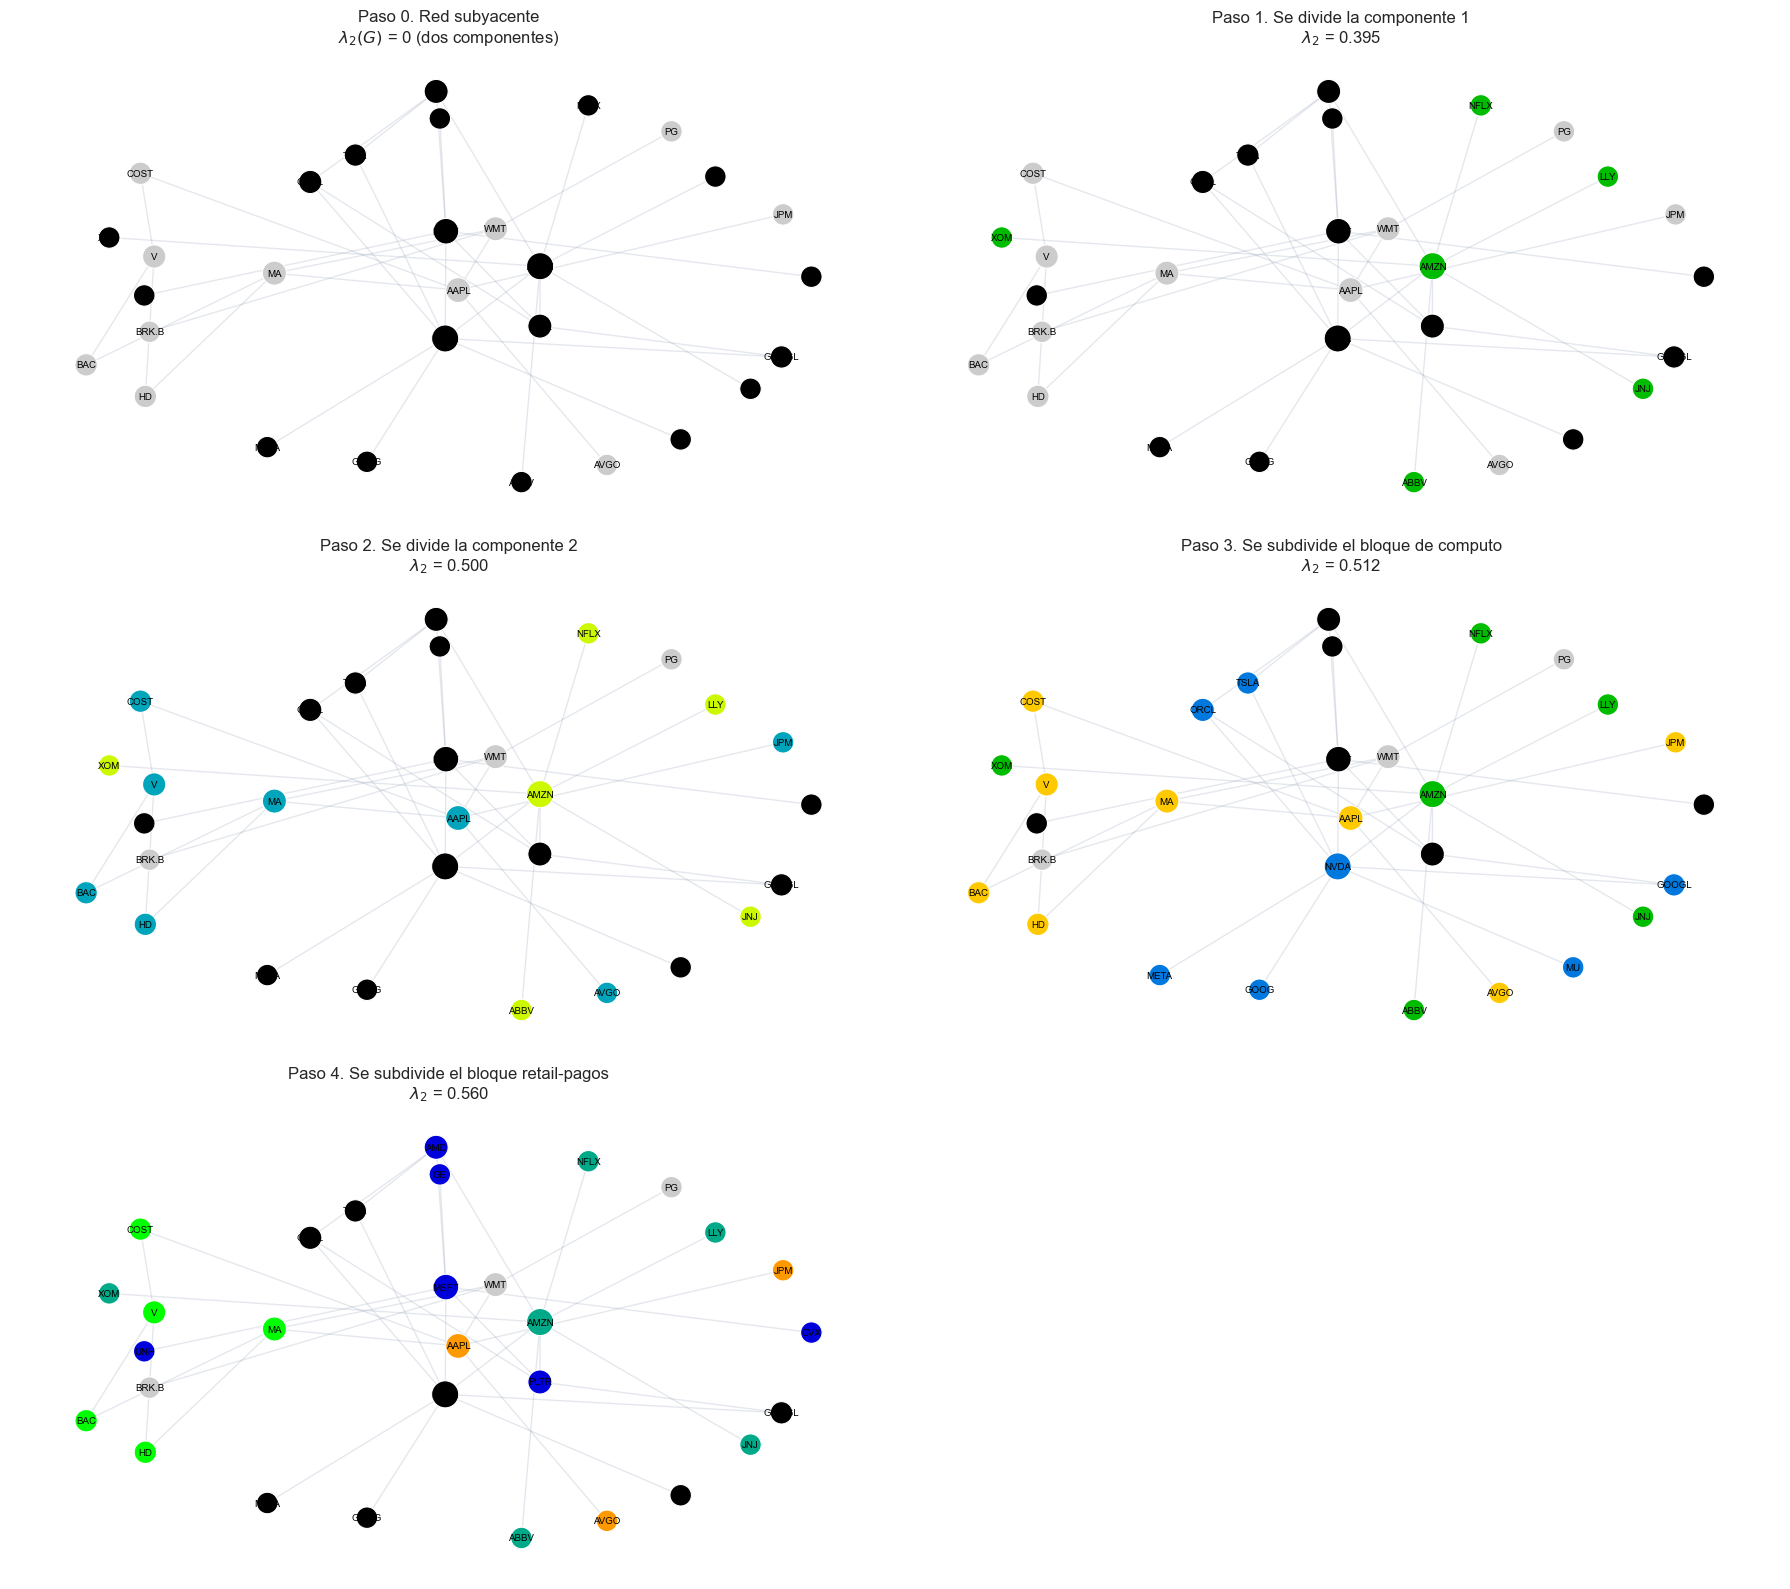

In [5]:
state_sp_after_c1 = [set(part) for part in report_sp_c1["groups"]] + [set(componentes_sp[1])]
state_sp_after_c2 = coarse_partition_sp
state_sp_after_c1_big = []
for part in report_sp_c1["groups"]:
    if set(part) == set(sp_c1_big):
        state_sp_after_c1_big.extend([set(child) for child in report_sp_c1_big["groups"]])
    else:
        state_sp_after_c1_big.append(set(part))
state_sp_after_c1_big.extend([set(part) for part in report_sp_c2["groups"]])

states_sp = [
    {
        "title": "Paso 0. Red subyacente\n$\lambda_2(G)$ = 0 (dos componentes)",
        "groups": componentes_sp,
    },
    {
        "title": f"Paso 1. Se divide la componente 1\n$\lambda_2$ = {report_sp_c1['lambda2']:.3f}",
        "groups": state_sp_after_c1,
    },
    {
        "title": f"Paso 2. Se divide la componente 2\n$\lambda_2$ = {report_sp_c2['lambda2']:.3f}",
        "groups": state_sp_after_c2,
    },
    {
        "title": f"Paso 3. Se subdivide el bloque de computo\n$\lambda_2$ = {report_sp_c1_big['lambda2']:.3f}",
        "groups": state_sp_after_c1_big,
    },
    {
        "title": f"Paso 4. Se subdivide el bloque retail-pagos\n$\lambda_2$ = {report_sp_c2_big['lambda2']:.3f}",
        "groups": refined_partition_sp,
    },
]

plot_partition_sequence(G_sp, labels_sp, states_sp, pos=pos_sp, ncols=2, figsize=(18, 16))

## 3. Comparacion con modularidad

En la notebook de modularidad se habia trabajado sobre la **componente principal** y aparecian **5 comunidades** bastante locales.
Aqui agrego dos comparaciones:

- contra `greedy_modularity_communities` en la **red completa** no dirigida, para poder comparar particiones sobre el mismo grafo;
- contra la **componente principal** de la actividad anterior, para ver que tanto coinciden las lecturas.

,grafo,metodo,grupos,Q
0,SP500 completo,greedy_modularity_communities,4,0.5453
1,SP500 completo,espectral laplaciano (4 grupos),4,0.5307
2,SP500 completo,espectral laplaciano refinado (6 grupos),6,0.4865
3,SP500 componente principal,greedy_modularity_communities,5,0.3715


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,11,13,0.2364,0.4998,"AAPL, AVGO, BAC, BRK.B, COST, HD, JPM, MA, PG, V, WMT"
1,2,9,10,0.2778,0.7260,"AMD, GOOG, GOOGL, META, MU, NVDA, ORCL, PLTR, TSLA"
2,3,6,5,0.3333,1.0000,"ABBV, AMZN, JNJ, LLY, NFLX, XOM"
3,4,4,3,0.5000,1.0000,"CVX, GE, MSFT, UNH"


,grupo,nodos,aristas_internas,densidad,lambda_2,miembros
0,1,6,5,0.3333,1.0,"ABBV, AMZN, JNJ, LLY, NFLX, XOM"
1,2,4,3,0.5000,1.0,"GOOG, META, MU, NVDA"
2,3,4,3,0.5000,1.0,"CVX, GE, MSFT, UNH"
3,4,3,2,0.6667,1.0,"GOOGL, ORCL, PLTR"
4,5,2,1,1.0000,2.0,"AMD, TSLA"


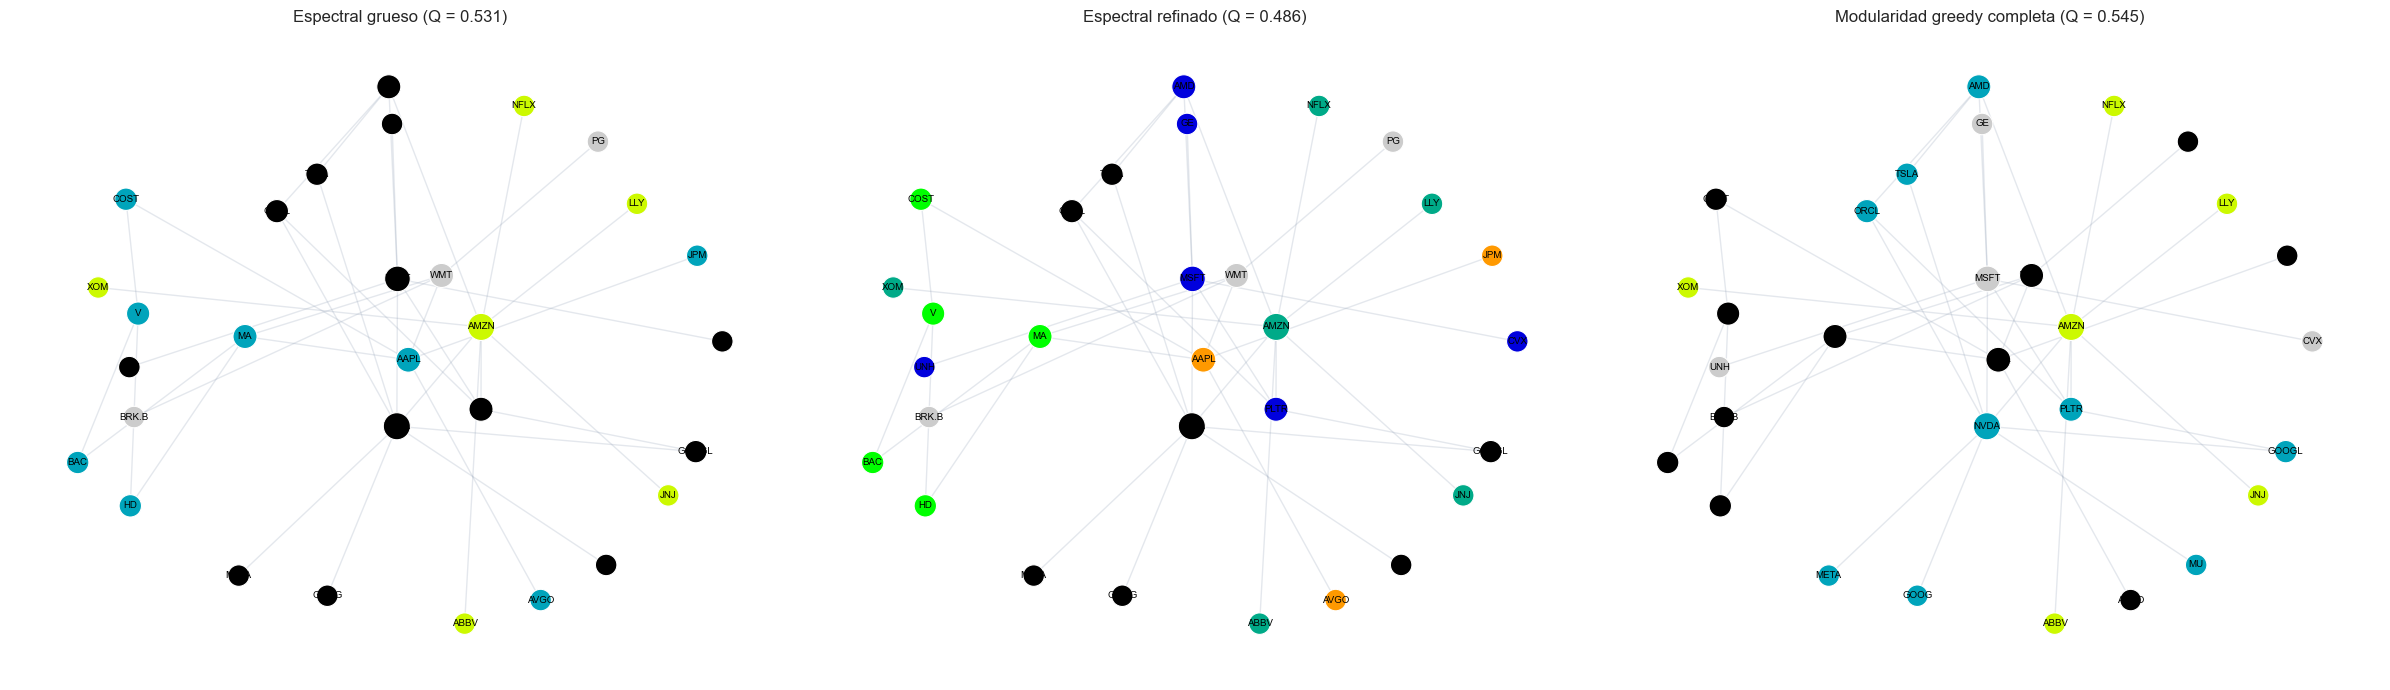

In [6]:
comunidades_mod_full_sp = sorted(list(greedy_modularity_communities(G_sp)), key=len, reverse=True)
q_spectral4_sp = nx.algorithms.community.modularity(G_sp, coarse_partition_sp)
q_spectral6_sp = nx.algorithms.community.modularity(G_sp, refined_partition_sp)
q_mod_full_sp = nx.algorithms.community.modularity(G_sp, comunidades_mod_full_sp)

G_sp_main = G_sp.subgraph(componentes_sp[0]).copy()
labels_sp_main = get_display_labels(G_sp_main)
comunidades_mod_main_sp = sorted(list(greedy_modularity_communities(G_sp_main)), key=len, reverse=True)
q_mod_main_sp = nx.algorithms.community.modularity(G_sp_main, comunidades_mod_main_sp)

comparacion_sp = comparison_table(
    [
        {
            "grafo": "SP500 completo",
            "metodo": "greedy_modularity_communities",
            "grupos": len(comunidades_mod_full_sp),
            "Q": round(q_mod_full_sp, 4),
        },
        {
            "grafo": "SP500 completo",
            "metodo": "espectral laplaciano (4 grupos)",
            "grupos": len(coarse_partition_sp),
            "Q": round(q_spectral4_sp, 4),
        },
        {
            "grafo": "SP500 completo",
            "metodo": "espectral laplaciano refinado (6 grupos)",
            "grupos": len(refined_partition_sp),
            "Q": round(q_spectral6_sp, 4),
        },
        {
            "grafo": "SP500 componente principal",
            "metodo": "greedy_modularity_communities",
            "grupos": len(comunidades_mod_main_sp),
            "Q": round(q_mod_main_sp, 4),
        },
    ]
)

display(comparacion_sp)
display(partition_summary(G_sp, comunidades_mod_full_sp, labels_sp))
display(partition_summary(G_sp_main, comunidades_mod_main_sp, labels_sp_main))

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
draw_partition(
    axes[0],
    G_sp,
    coarse_partition_sp,
    labels_sp,
    title=f"Espectral grueso (Q = {q_spectral4_sp:.3f})",
    pos=pos_sp,
)
draw_partition(
    axes[1],
    G_sp,
    refined_partition_sp,
    labels_sp,
    title=f"Espectral refinado (Q = {q_spectral6_sp:.3f})",
    pos=pos_sp,
)
draw_partition(
    axes[2],
    G_sp,
    comunidades_mod_full_sp,
    labels_sp,
    title=f"Modularidad greedy completa (Q = {q_mod_full_sp:.3f})",
    pos=pos_sp,
)
plt.tight_layout()
plt.show()

**Conclusion**

- El tratamiento correcto aqui es **no aplicar directamente el tutorial a la red dirigida**. La version del algoritmo vista en clase usa la Laplaciana simetrica; por eso convierto la red a su forma **subyacente no dirigida**. Si quisiera respetar completamente la direccion, tendria que pasar a una teoria de Laplacianos dirigidos o cadenas de Markov, que ya es otra metodologia.
- Las particiones espectrales tienen sentido como lectura de **bloques de dependencia alrededor de hubs**. `AMZN`, `MSFT`, `NVDA`, `AAPL` y `WMT` dominan la forma de los cortes.
- Para describir comunidades economicas estables, **prefiero modularidad** en esta red: en la red completa obtiene una $Q$ mas alta y en la componente principal produce grupos mas finos, como `AMD-TSLA` y `GOOGL-ORCL-PLTR`, que el Laplaciano no separa de manera natural sin forzar demasiado el arbol.
- Aun asi, el agrupamiento espectral si aporta algo valioso: muestra muy bien **que bloques estan casi colgados de un hub** y en que punto una subdivisión adicional deja de ser una comunidad real para convertirse en una hoja aislada del grafo.